In [ ]:
# 📈 선형회귀 직접 구현하기

> 머신러닝 첫걸음. **선형회귀는 "딥러닝의 씨앗"** 입니다.
> 이 노트북은 **외부 모듈·클래스 없이**, 공식을 numpy로 **직접 한 줄씩** 구현합니다.
> 여기서 배우는 **손실함수·경사하강법**이 이후 모든 모델의 뼈대입니다.

## 오늘의 흐름
1. 모델 `ŷ = wx + b` 2. 손실 MSE 3. 최소제곱(공식) 4. **경사하강법(직접 for 루프)** 5. 평가 R²

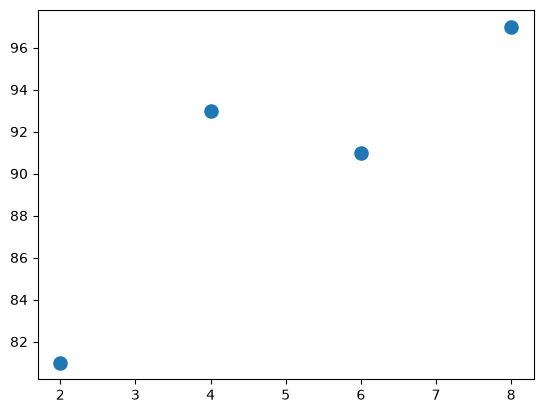

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# study time- x record -y
x = np.array([2 ,4, 6, 8])
y = np.array([81, 93, 91, 97])
plt.scatter(x,y, s=90)
plt.show()


## 준비 — 오늘의 데이터: 공부시간 → 성적

머신러닝의 목표 한 문장: **"입력 x로 출력 y를 예측하는 규칙을 데이터에서 찾는다."**

## 1️⃣ 모델 — 직선 `ŷ = wx + b`

- **① 무엇**: 예측을 직선으로. `w`=기울기, `b`=절편.
- **② 왜**: 파라미터가 딱 2개라 가장 단순하고, "많을수록 커진다"를 잘 잡음.
- **③ 어떻게**: 데이터에 가장 잘 맞는 w, b를 찾음.
- **④ 비유**: 시소의 기울기(w)와 바닥 높이(b)를 조절해 점에 맞추기.

In [6]:
w, b = 2, 78
y_hat = w*x+b  #예측
print('predicted value y', y_hat)
print('real y', y)


predicted value y [82 86 90 94]
real y [81 93 91 97]


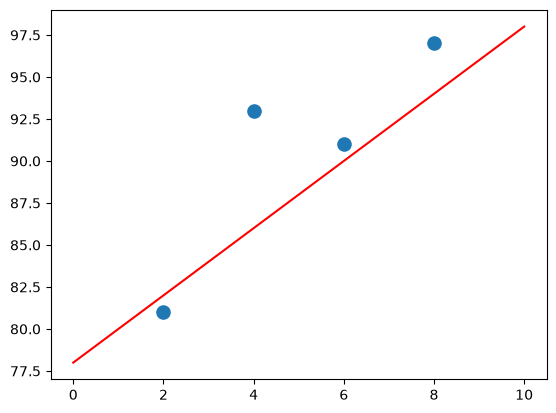

In [8]:
xg = np.linspace(0, 10, 100) #1부터 10까지 100등분하라는 뜻
plt.scatter(x,y, s=90, label='real')
plt.plot(xg, w*xg +b, 'r', label=f'prediction w ={w}, b={b}')
plt.show()

## 2️⃣ 손실 MSE — "얼마나 틀렸나"를 숫자로

- **① 무엇**: 예측이 틀린 정도를 하나의 숫자로 = **MSE(평균제곱오차)**.
- **② 왜**: 좋은 직선을 눈대중이 아니라 **숫자로** 정의해야 컴퓨터가 최적을 찾음.
- **③ 어떻게**: 오차(실제−예측)를 **제곱해서 평균**. `MSE = (1/n)Σ(y − ŷ)²`
- **④ 왜 제곱?** ① 부호 상쇄 방지 ② 큰 오차에 큰 벌점 ③ 미분이 매끈.

In [9]:
error = y - y_hat
mse = (error **2).mean()
print('오차 :',error)
print('오차의제곱:', error **2)
print('MSE: ', mse)

오차 : [-1  7  1  3]
오차의제곱: [ 1 49  1  9]
MSE:  15.0


In [10]:
#W를 변경
for w_try in [1,2,3,4,5]:
    m = ((y - (w_try * x + b))**2).mean()
    print(f'w:{w_try}, b:{b} ->mse:{m:.2f}')

w:1, b:78 ->mse:73.00
w:2, b:78 ->mse:15.00
w:3, b:78 ->mse:17.00
w:4, b:78 ->mse:79.00
w:5, b:78 ->mse:201.00


## 3️⃣ 방법 1 · 최소제곱 — 공식으로 한 방에

- **① 무엇**: MSE를 미분해서 0이 되는 지점을 직접 푼 공식. 반복 없이 최적해.
- **② 왜**: 손실 그래프(그릇 모양)의 **바닥은 기울기 0**. 미분=0을 풀면 바닥.
- **③ 공식**:
  $$ w = \frac{\sum (x-\bar{x})(y-\bar{y})}{\sum (x-\bar{x})^2}, \qquad b = \bar{y} - w\bar{x} $$
- **④ 비유**: 산 정상에서 물을 부으면 가장 낮은 곳으로 흐르듯, 미분=0이 바닥을 콕 집음.

## 4️⃣ 방법 2 · 경사하강법 — 조금씩 굴러 내려가기 ⭐ (딥러닝의 심장)

- **① 무엇**: 공식 없이도 통하는 범용 방법. 아무 데서나 출발해 **손실 줄어드는 방향으로 한 걸음씩**.
- **② 왜**: 딥러닝은 파라미터가 수백만 개라 공식 해가 없음 → 반복적으로 내려가야 함.
- **③ 어떻게**: 손실을 w, b로 **편미분**해서 기울기를 구하고, 그 반대로 학습률 η만큼 이동. 반복.
  $$ \frac{\partial L}{\partial w} = \frac{2}{n}\sum -x(y-\hat{y}), \quad \frac{\partial L}{\partial b} = \frac{2}{n}\sum -(y-\hat{y}) $$
  $$ w \leftarrow w - \eta\frac{\partial L}{\partial w}, \qquad b \leftarrow b - \eta\frac{\partial L}{\partial b} $$
- **④ 비유**: 안개 낀 산에서 발밑 경사만 보고 가장 가파른 내리막으로 한 걸음씩 → 골짜기 도달.

아래 for 루프가 경사하강법의 전부입니다. 한 줄씩 읽어보세요.

In [13]:
w = 0.0 #임의의 기울기, 하이퍼파라미터
b = 0.0 #임의의 편향(y절편)
lr = 0.01 #학습률
epochs = 2001 #학습 반복 횟수
n = len(x)
hist_w, hist_b, hist_loss = [], [], []
for i in range(epochs):
    y_hat = w*x +b #predicted
    error = y - y_hat #error
    w_diff = (2/n) * sum(-x * error) #손실을 w로 편미분
    b_diff = (2/n) *sum(-error) #손실을 b로 편미분
    w = w -lr * w_diff #update w 기울기반대
    b = b-lr *b_diff #update b
    hist_w.append(w); hist_b.append(b); hist_loss.append((error**2).mean())
    if i % 200 ==0:
        print(f'epoch {i:>4}: w={w:.3f}, b={b:.3f}, mse={(error**2).mean()}')
print(f'/n result:w={w:.3f},{b:.3f}')
    
    

epoch    0: w=9.280, b=1.810, mse=8225.0
epoch  200: w=8.970, b=39.194, mse=274.1417564360012
epoch  400: w=5.784, b=58.211, mse=80.80726526041698
epoch  600: w=4.119, b=68.143, mse=28.076063723120157
epoch  800: w=3.250, b=73.330, mse=13.693841499555466
epoch 1000: w=2.796, b=76.039, mse=9.771148481803971
epoch 1200: w=2.559, b=77.454, mse=8.701249806041249
epoch 1400: w=2.435, b=78.192, mse=8.40943926384015
epoch 1600: w=2.371, b=78.578, mse=8.329849117157325
epoch 1800: w=2.337, b=78.780, mse=8.30814122613591
epoch 2000: w=2.319, b=78.885, mse=8.302220486543936
/n result:w=2.319,78.885


### 🎬 경사하강 과정을 눈으로 — 직선이 점점 맞춰진다

### 📉 손실 곡선 — 반복할수록 줄어든다

### 🧪 학습률(η) 실험 — 너무 크면 터지고, 너무 작으면 굼벵이
학습률은 **한 걸음의 보폭**입니다. 직접 바꿔서 망가뜨려 보면 감이 옵니다.

## 5️⃣ 평가 — R² (결정계수)

- **① 무엇**: 모델이 데이터 변동을 **몇 %나 설명**하는지. 1에 가까울수록 좋음.
- **③ 공식**: $R^2 = 1 - \dfrac{\sum(y-\hat{y})^2}{\sum(y-\bar{y})^2}$ (1=완벽, 0=평균으로 찍기, 음수=그보다 못함).
- **④ 비유**: 시험 범위 중 몇 %를 커버했나.

## 🧠 오늘의 3줄 요약
1. **모델**: `ŷ = wx + b` — 파라미터 2개짜리 직선.
2. **손실**: MSE로 틀린 정도를 숫자화 → 이걸 최소화하는 게 학습.
3. **최적화**: 최소제곱(공식) 또는 **경사하강법(for 루프)**. 딥러닝은 경사하강법을 씁니다.

## 🔗 딥러닝으로 가는 다리
| 오늘 배운 것 | 딥러닝에서 |
|---|---|
| 가설 `y=wx+b` | 뉴런 1개(활성함수 없음) |
| 손실 MSE | Cross-Entropy 등으로 확장 |
| 경사하강 for 루프 | 역전파 + SGD/Adam |

---

# 🎯 실습 문제 — 키로 몸무게 예측하기 (실제 데이터)

`data/heights.csv` 는 실제 사람들의 **키(height, inch)** 와 **몸무게(weight, lb)** 200명 데이터입니다.
이 실제 데이터로 직접 선형회귀를 구현해 문제를 풀어보세요. (배운 코드를 그대로 응용)

### 📝 문제
1. **최소제곱 공식**으로 기울기 `w`와 절편 `b`를 구하세요.
2. **경사하강법 for 루프**로 같은 w, b가 나오는지 확인하세요. (힌트: 키 값이 커서 lr을 아주 작게, 또는 표준화)
3. 키가 **70 inch** 인 사람의 몸무게는 얼마로 예측되나요?
4. 이 모델의 **R²** 를 구하세요.
5. 기울기 w의 **의미**를 한 문장으로 설명하세요. (키 1 inch↑ → 몸무게 ?)

> 먼저 스스로 풀어본 뒤, 아래 정답 예시와 비교하세요.

### ✅ 정답 예시

### 🔥 도전 문제
- 데이터를 **훈련/검증으로 나눠**(numpy로 인덱스 섞기) 검증 R²를 구해보세요.
- 학습률을 너무 크게 주면(표준화 안 한 원본 키로) 경사하강이 발산하는지 확인하세요.

---